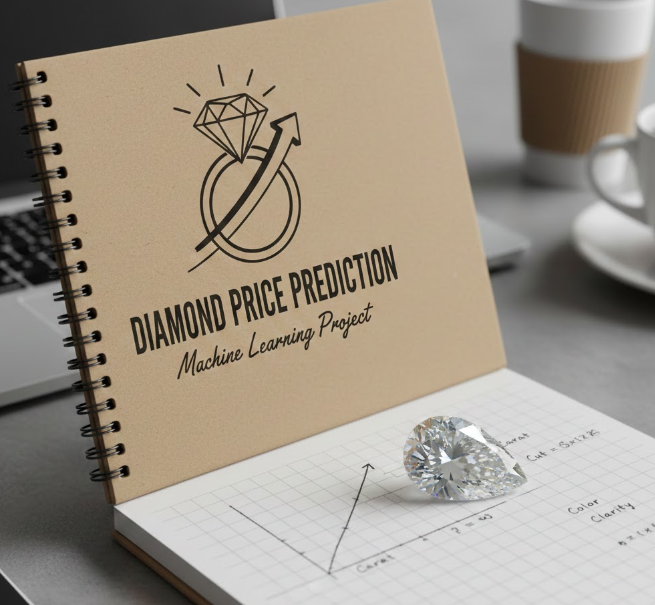

# 1.0 About Author
**Project:** Netflix EDA <br>
**Author:** Muhammad Hanzla <br>
**Code Submission Date:** 20-12-2025 <br>
**Author's Contact Info:** \
   [Email](mailto:muhammadhanzlaaltaf@gmail.com) <br>
   [Kaggle](https://www.kaggle.com/muhammadhanzla1234) <br>
   [Linkedin](https://www.linkedin.com/in/muhammad-hanzla-17a79237a/overlay/about-this-profile/?lipi=urn%3Ali%3Apage%3Ad_flagship3_profile_view_base%3BXZVL79YzTWCLRumjJpyHFQ%3D%3D) <br>
   [Instagram](https://www.instagram.com/m.hanzlaaltaf/?hl=en) 

# 2.0 About Data
Data: Diamond <br>
Data Age: This data was collected in 2016 <br>
**Dataset:** [🔗link](https://www.kaggle.com/datasets/shivam2503/diamonds)

## 2.1 Objective:
The goal of this project is to build a machine learning model that predicts the price of a diamond based on its physical and qualitative attributes such as carat, cut, color, clarity, and dimensions.

## 2.2 Tasks to Perform

#### 1. Exploratory Data Analysis (EDA)
- Understand feature distributions  
- Analyze relationships between features and price  
- Detect outliers and anomalies  

#### 2. Data Preprocessing
- Handle missing or invalid values  
- Encode categorical variables (`cut`, `color`, `clarity`)  
- Apply feature scaling if required  

#### 3. Feature Engineering
- Create new features if helpful  
  - **Volume** = `x × y × z`  
- Remove redundant or highly correlated features  

#### 4. Model Building
Train and compare the following regression models:
- Linear Regression  
- Random Forest Regressor  
- Gradient Boosting / XGBoost  

#### 5. Model Evaluation
Evaluate model performance using:
- Mean Absolute Error (MAE)  
- Mean Squared Error (MSE)  
- R² Score  

#### 6. Hyperparameter Tuning
- Optimize model parameters using:
  - GridSearchCV  
  - RandomizedSearchCV  

#### 7. Model Interpretation
- Analyze feature importance  
- Identify which factors influence diamond prices the most  


## 2.3 Kernel Version Used
* Python 3.10.10

# 3.0 Libraries Used
*We will use the following libraries* <br>
**Pandas:** Data manipulation and analysis library. <br>
**Numpy:** Numerical computing library. <br>
**Matplotlib:** Data visualization library. <br>
**Seaborn:** Statistical data visualization library. <br>
**Scipy:** To provide a comprehensive set of numerical algorithms and tools for scientific computing in Python. <br>
**Scikit Learn:** To build, train, evaluate, and deploy machine learning models.


# 4.0 Exploratory Data Analysis (EDA)


# 4.1 Import Libraries

In [1]:
# hide all warnings runtime
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy as sp
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "iframe"
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor 
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# 4.2 Loading the Dataset

In [2]:
df=pd.read_csv('/kaggle/input/diamonds/diamonds.csv')
df=df.sample(20000,random_state=42)

## 4.3 Setting Max cols and Max rows View

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## 4.4 Understanding the Data

In [4]:
print("Top 5 rows of the dataset:")
df.head()

Top 5 rows of the dataset:


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
1388,1389,0.24,Ideal,G,VVS1,62.1,56.0,559,3.97,4.00,2.47
50052,50053,0.58,Very Good,F,VVS2,60.0,57.0,2201,5.44,5.42,3.26
41645,41646,0.40,Ideal,E,VVS2,62.1,55.0,1238,4.76,4.74,2.95
42377,42378,0.43,Premium,E,VVS2,60.8,57.0,1304,4.92,4.89,2.98
17244,17245,1.55,Ideal,E,SI2,62.3,55.0,6901,7.44,7.37,4.61


In [5]:
print('Basic Information')
df.info()

Basic Information
<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 1388 to 42680
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  20000 non-null  int64  
 1   carat       20000 non-null  float64
 2   cut         20000 non-null  object 
 3   color       20000 non-null  object 
 4   clarity     20000 non-null  object 
 5   depth       20000 non-null  float64
 6   table       20000 non-null  float64
 7   price       20000 non-null  int64  
 8   x           20000 non-null  float64
 9   y           20000 non-null  float64
 10  z           20000 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 1.8+ MB


In [6]:
# Total Numbers of Columns 
print(f'\nTotal Number of Columns: {df.shape[1]}')
print(f'Total Number of Rows: {df.shape[0]}')


Total Number of Columns: 11
Total Number of Rows: 20000


## 4.5 Summarize the data

In [7]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,26801.326450,0.796141,61.752835,57.443465,3908.501700,5.727281,5.730017,3.536041
std,15586.548782,0.471719,1.431536,2.260135,3958.733294,1.122634,1.129743,0.694116
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13259.750000,0.400000,61.100000,56.000000,942.000000,4.707500,4.710000,2.910000
50%,26822.500000,0.700000,61.900000,57.000000,2409.000000,5.700000,5.710000,3.530000
75%,40246.250000,1.040000,62.500000,59.000000,5290.250000,6.540000,6.540000,4.030000
max,53937.000000,4.010000,79.000000,95.000000,18823.000000,10.140000,31.800000,6.310000


In [8]:
# Identifying categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print("Categorical Columns:",categorical_cols)
Numeric_cols=df.select_dtypes(include=['int64','float64']).columns
print("Numeric Columns:",Numeric_cols)

Categorical Columns: Index(['cut', 'color', 'clarity'], dtype='object')
Numeric Columns: Index(['Unnamed: 0', 'carat', 'depth', 'table', 'price', 'x', 'y', 'z'], dtype='object')


## 4.6 Data Cleaning

### 4.6.1 Missing Values



Total Missing Values in each Column:
Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64


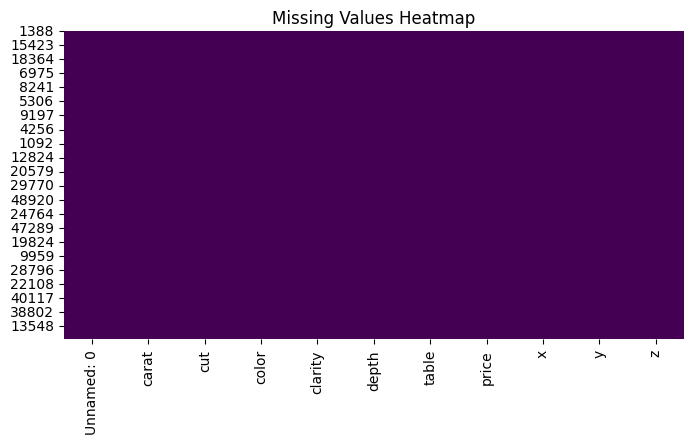

In [9]:
## Total Missing values
print('\nTotal Missing Values in each Column:')
print(df.isnull().sum())
# Visualizing missing values
plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

` No missing values in Whole Dataset , Dataset is completely populated`

### 4.6.2 Duplicate rows

In [10]:
duplicates=df.duplicated().sum()
print(duplicates)   

0


` There in no Duplicates in the Dataset`

### 4.6.3 Outliers

In [11]:
# Remove the outliers using Z-score method
from scipy import stats
z = np.abs(stats.zscore(df['price']))
df_filtered = df[z < 3]  # threshold of 3
print(f'Original DataFrame shape: {df.shape}')
print(f'Filtered DataFrame shape: {df_filtered.shape}')
df = df_filtered

Original DataFrame shape: (20000, 11)
Filtered DataFrame shape: (19544, 11)


`outliers removed from the dataset`

## 4.7 Data Encoding

In [12]:
le=LabelEncoder()
for col in categorical_cols:
    df[col]=le.fit_transform(df[col])   
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
1388,1389,0.24,2,3,6,62.1,56.0,559,3.97,4.00,2.47
50052,50053,0.58,4,2,7,60.0,57.0,2201,5.44,5.42,3.26
41645,41646,0.40,2,1,7,62.1,55.0,1238,4.76,4.74,2.95
42377,42378,0.43,3,1,7,60.8,57.0,1304,4.92,4.89,2.98
17244,17245,1.55,2,1,3,62.3,55.0,6901,7.44,7.37,4.61


# 5.0 Machine Learning Model

## 5.1 Split the Data into X and Y

In [13]:
# Split the data
X=df.drop('price',axis=1)
y=df['price']

## 5.2 Train Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## 5.3 Hyperparameter Tunning

In [15]:
%%time
# Create a dictionaries of list of models to evaluate performance with hyperparameters
models = { 
         'LinearRegression': (LinearRegression(), {}),
    
    'SVR': (SVR(), {
        'kernel': ['rbf'],              # only rbf
        'C': [1, 10],
        'gamma': [0.1, 0.01],
        'epsilon': [0.01, 0.1]
    }),
    
    'DecisionTreeRegressor': (DecisionTreeRegressor(), {
        'max_depth': [5, 10],
        'splitter': ['best']
    }),
    'RandomForestRegressor': (RandomForestRegressor(), {
        'n_estimators': [50, 100],
        'max_depth': [5, 10]
    }),
    
    'KNeighborsRegressor': (KNeighborsRegressor(), {
        'n_neighbors': [3, 5, 7],
        'weights': ['uniform', 'distance']
    }),
    
    'GradientBoostingRegressor': (GradientBoostingRegressor(), {
    'loss': ['squared_error', 'absolute_error'],  # replace 'lad' with 'absolute_error'
    'n_estimators': [50, 100],
    'learning_rate': [0.1, 0.05]
}),

     'XGBRegressor': (XGBRegressor(), {
        'n_estimators': [50, 100],
        'learning_rate': [0.1, 0.05]
    }), 
    'CatBoostRegressor': (CatBoostRegressor(verbose=0), {  # quiet mode
        'iterations': [100, 200],
        'depth': [4, 6],
        'learning_rate': [0.1, 0.05]
    })        

          }
# train and predict each model with evaluation metrics as well making a for loop to iterate over the models

for name, (model, params) in models.items():
    # create a pipline
    pipeline = GridSearchCV(model, params, cv=5)
    
    # fit the pipeline
    pipeline.fit(X_train, y_train)
    
    # make prediction from each model
    y_pred = pipeline.predict(X_test)
    
      
    # print the performing metric
    print(name, 'MSE: ', mean_squared_error(y_test, y_pred))
    print(name, 'R2: ', r2_score(y_test, y_pred))
    print(name, 'MAE: ', mean_absolute_error(y_test, y_pred))
    print('\n')

LinearRegression MSE:  2098229.4993005325
LinearRegression R2:  0.8192905226073638
LinearRegression MAE:  783.7373338256007


SVR MSE:  12755719.248739729
SVR R2:  -0.09858304822011577
SVR MAE:  2431.0892681192904


DecisionTreeRegressor MSE:  2426.7963734696827
DecisionTreeRegressor R2:  0.9997909927848531
DecisionTreeRegressor MAE:  17.20694541684377


RandomForestRegressor MSE:  2059.4229910224008
RandomForestRegressor R2:  0.9998226327231783
RandomForestRegressor MAE:  13.15268978328543


KNeighborsRegressor MSE:  156247.14159315056
KNeighborsRegressor R2:  0.9865432550105677
KNeighborsRegressor MAE:  47.67091471670737


GradientBoostingRegressor MSE:  30403.958121498883
GradientBoostingRegressor R2:  0.9973814669059627
GradientBoostingRegressor MAE:  105.87259293791693


XGBRegressor MSE:  1633.1531982421875
XGBRegressor R2:  0.9998593330383301
XGBRegressor MAE:  24.14361000061035


CatBoostRegressor MSE:  11151.290350979272
CatBoostRegressor R2:  0.9990395979790339
CatBoostRegres

`Random Forest Regressor is the best Model among them `

## 5.4 Saving the Model

In [16]:
import joblib
# Save the best model, assuming CatBoostRegressor performed the best
joblib.dump(pipeline, 'best_diamond_price_model.pkl')
print("Model saved successfully")


Model saved successfully


## 5.5 Loading the model

In [17]:
# Load model
model = joblib.load("best_diamond_price_model.pkl")

print("Model loaded successfully")

Model loaded successfully


In [18]:
df.head(1)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
1388,1389,0.24,2,3,6,62.1,56.0,559,3.97,4.0,2.47


## 5.6 Testing the Model

In [19]:
expected_cols = model.best_estimator_.feature_names_

new_data = pd.DataFrame(
    [[0, 0.24, 2, 3, 6, 62.1, 56.0, 3.97, 4.0, 2.47]],
    columns=expected_cols
)

model.predict(new_data)


array([527.67634401])

` If this notebook helped you, please upvote 👍` \
` Suggestions and questions are always welcome! `  \
` Best wishes! `


